In [1]:
!mamba install pandas matplotlib seaborn

mambajs 0.21.4

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, seaborn
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 3.404 seconds
  Name           Version  Build                Channel
--------------------------------------------------------------------
+ pandas         3.0.5    np23py313h1e705a5_0  emscripten-forge-4x
+ patsy          1.0.2    py313h1804a44_3      emscripten-forge-4x
+ python-tzdata  2026.3   pyhd8ed1ab_0         conda-forge
+ seaborn        0.13.2   hd8ed1ab_3           conda-forge
+ seaborn-base   0.13.2   pyhd8ed1ab_3         conda-forge
+ statsmodels    0.14.6   np23py313hd8db738_2  emscripten-forge-4x
- pip            26.1.2   pyh145f28c_0         conda-forge


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df = pd.read_csv("final_ml_ready_support_tickets (1).csv", on_bad_lines="skip")




In [13]:
# Drop tag_7 and tag_8 columns from the dataframe
df_cleaned = df.drop(columns=["tag_7", "tag_8"], errors="ignore")

In [14]:
print("New shape:", df_cleaned.shape)

New shape: (17217, 17)


In [15]:
# Fill missing categorical values with 'Unknown'
categorical_cols = [
    "version",
    "tag_2",
    "tag_3",
    "tag_4",
    "tag_5",
    "tag_6",
    "answer",
]
for col in categorical_cols:
  if col in df_cleaned.columns:
    df_cleaned[col] = df_cleaned[col].fillna("Unknown")

In [16]:
# Check missing values in df_cleaned
missing_summary = df_cleaned.isnull().sum()
print("Missing values per column:\n", missing_summary[missing_summary > 0])
print("\nTotal missing values:", missing_summary.sum())

Missing values per column:
 Series([], dtype: int64)

Total missing values: 0


In [32]:
print("First 3 Rows")
print(df[["type",  "priority" , "queue"]].head(3))

First 3 Rows
       type priority                  queue
0  Incident     high      Technical Support
1   Request   medium  Returns and Exchanges
2   Request      low   Billing and Payments


In [34]:
duplicate_rows = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_rows}")

if duplicate_rows > 0:
    print("Here are the first few duplicate rows:")
    print(df[df.duplicated()].head())
else:
    print("No duplicate rows found.")

Number of duplicate rows: 0
No duplicate rows found.


In [35]:
print("Complaint Type vs Priority")
cross_tab = pd.crosstab(df["type"], df["priority"])
print(cross_tab)

Complaint Type vs Priority
priority  high   low  medium
type                        
Change     708   352     731
Incident  2893  1269    2681
Problem   1300   737    1518
Request   1681  1143    2204


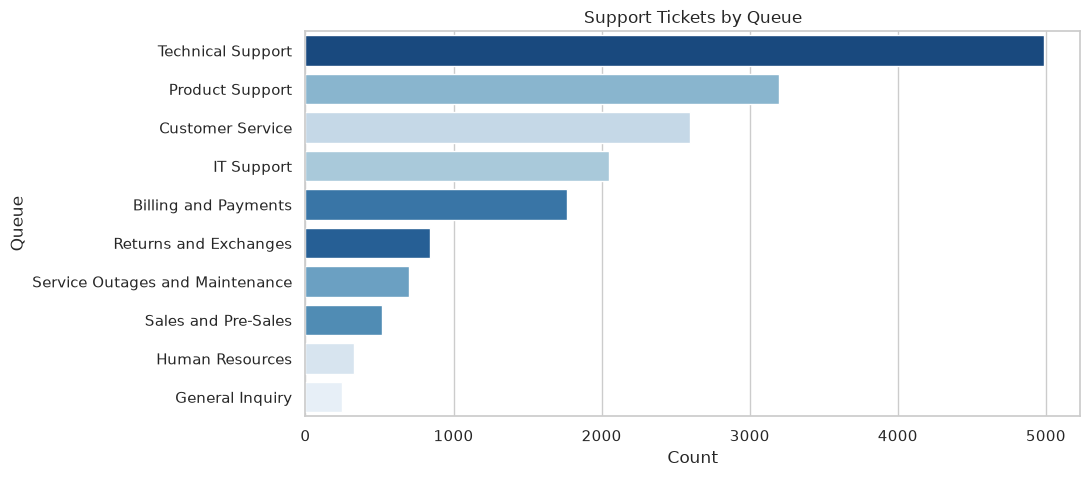

In [28]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 5))
sns.countplot(
    data=df_cleaned,
    y="queue",
    order=df_cleaned["queue"].value_counts().index,
    palette="Blues_r",
    hue="queue",
    legend=False,
)
plt.title("Support Tickets by Queue")
plt.xlabel("Count")
plt.ylabel("Queue")
plt.show()

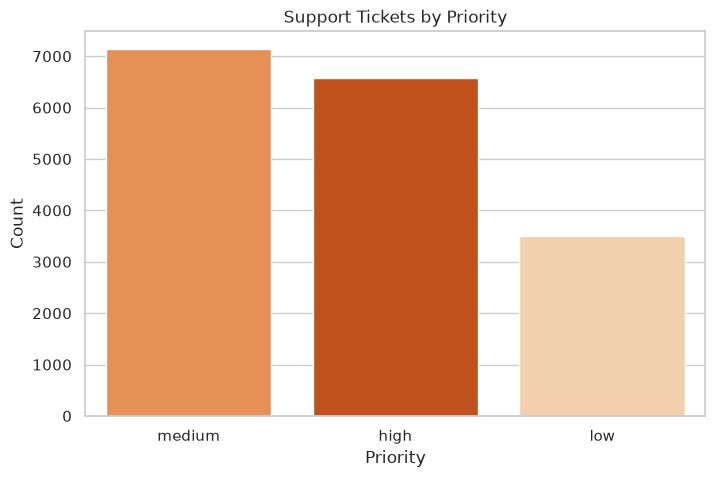

In [29]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df_cleaned,
    x="priority",
    order=df_cleaned["priority"].value_counts().index,
    palette="Oranges_r",
    hue="priority",
    legend=False,
)
plt.title("Support Tickets by Priority")
plt.xlabel("Priority")
plt.ylabel("Count")
plt.show()

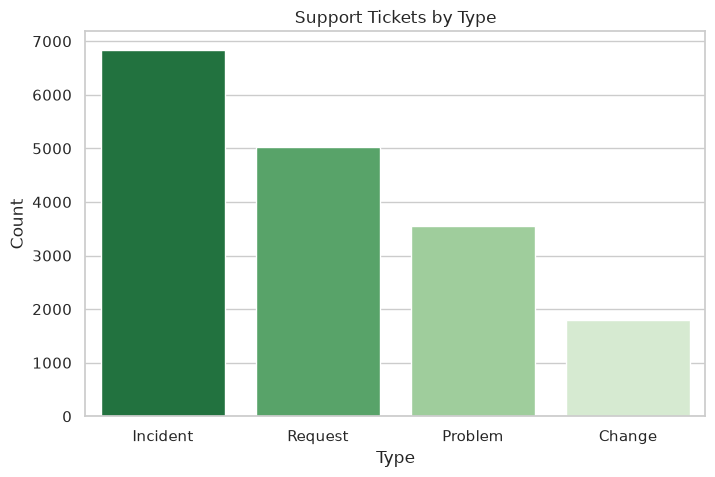

In [30]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df_cleaned,
    x="type",
    order=df_cleaned["type"].value_counts().index,
    palette="Greens_r",
    hue="type",
    legend=False,
)
plt.title("Support Tickets by Type")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

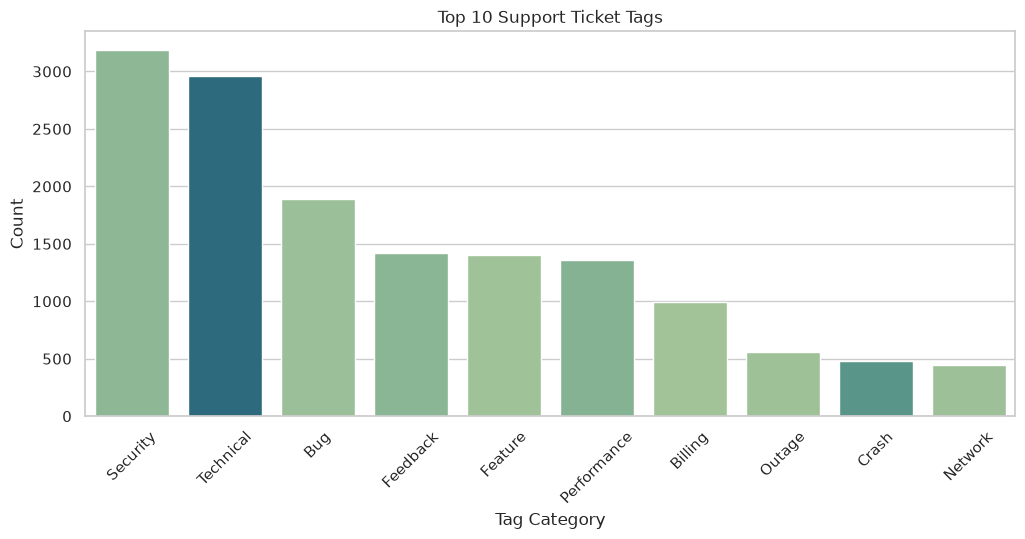

In [21]:
# Plot Top Tag 1 Categories
plt.figure(figsize=(12, 5))
sns.countplot(
    data=df_cleaned,
    x="tag_1",
    order=df_cleaned["tag_1"].value_counts().index[:10],
    palette="crest",
    hue="tag_1",
    legend=False,
)
plt.title("Top 10 Support Ticket Tags")
plt.xlabel("Tag Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

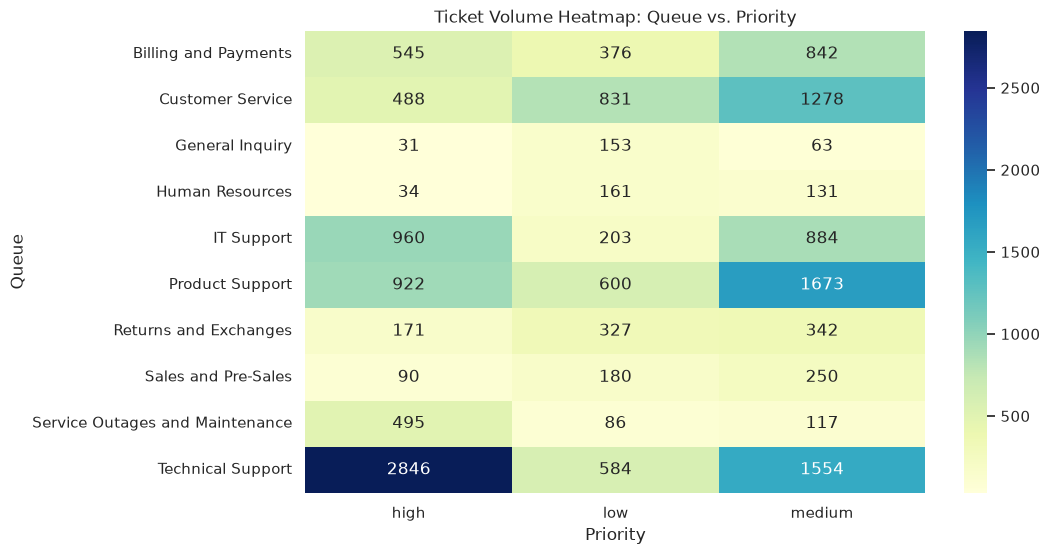

In [22]:
# Create a cross-tabulation of Queue vs. Priority
queue_priority_ct = pd.crosstab(df_cleaned["queue"], df_cleaned["priority"])

# Plot Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(queue_priority_ct, annot=True, fmt="d", cmap="YlGnBu", cbar=True)
plt.title("Ticket Volume Heatmap: Queue vs. Priority")
plt.xlabel("Priority")
plt.ylabel("Queue")
plt.show()

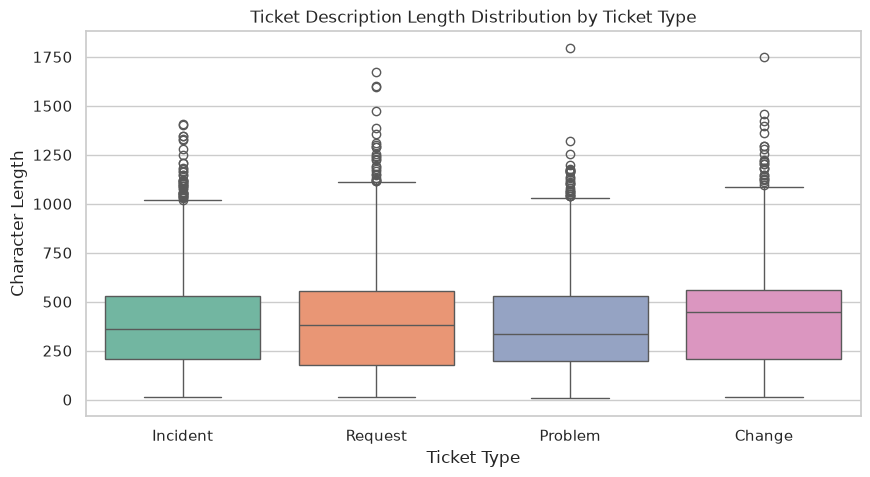

In [23]:
# Calculate character length of norm_body
df_cleaned["body_char_len"] = df_cleaned["norm_body"].apply(
    lambda x: len(str(x))
)

# Plot Boxplot
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df_cleaned,
    x="type",
    y="body_char_len",
    palette="Set2",
    hue="type",
    legend=False,
)
plt.title("Ticket Description Length Distribution by Ticket Type")
plt.xlabel("Ticket Type")
plt.ylabel("Character Length")
plt.show()

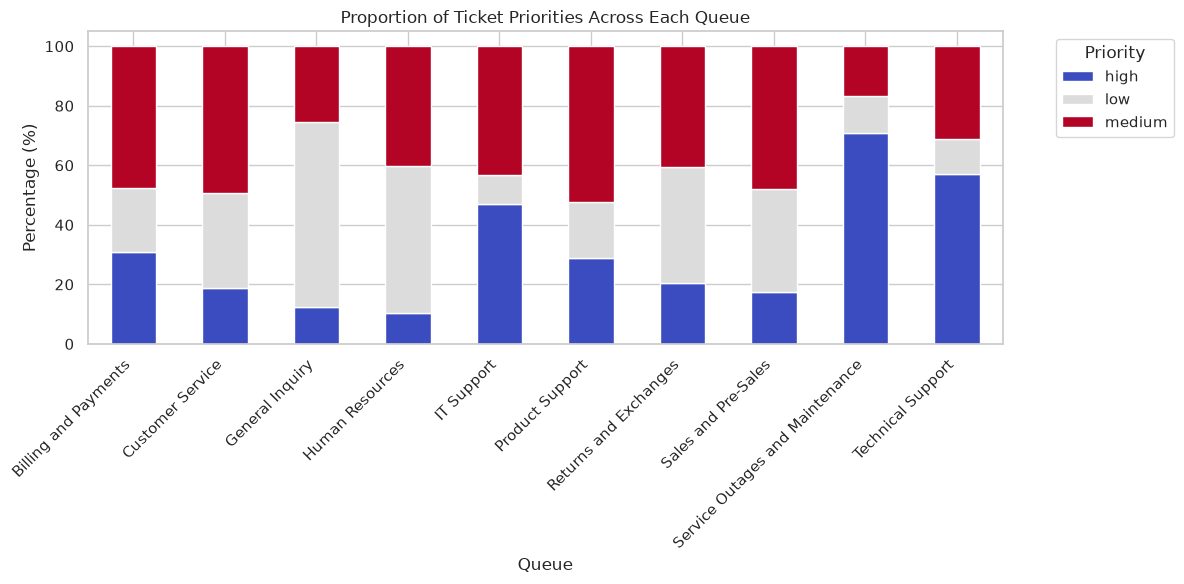

In [37]:
# Create cross-tabulation and normalize to show proportions (percentages)
queue_priority_prop = (
    pd.crosstab(df_cleaned["queue"], df_cleaned["priority"], normalize="index")
    * 100
)

# Plot stacked bar chart with a different colormap (e.g., 'coolwarm')
queue_priority_prop.plot(
    kind="bar", stacked=True, figsize=(12, 6), colormap="coolwarm"
)
plt.title("Proportion of Ticket Priorities Across Each Queue")
plt.xlabel("Queue")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Priority", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

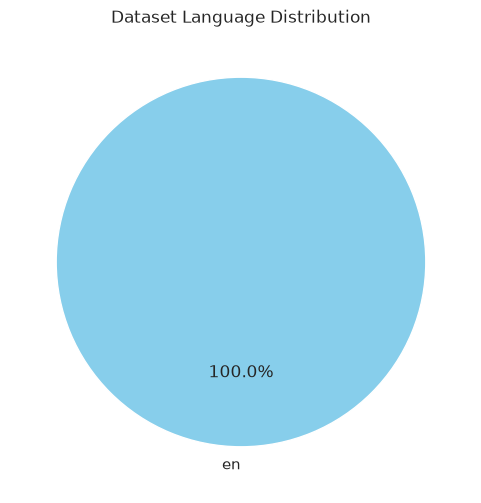

In [26]:
lang_counts = df_cleaned["language"].value_counts()

# Plot
plt.figure(figsize=(6, 6))
plt.pie(
    lang_counts,
    labels=lang_counts.index,
    autopct="%1.1f%%",
    colors=["skyblue"],
    startangle=90,
)
plt.title("Dataset Language Distribution")
plt.show()

In [31]:
print("Complaint Type vs Priority")
cross_tab = pd.crosstab(df["type"], df["priority"])
print(cross_tab)

Complaint Type vs Priority
priority  high   low  medium
type                        
Change     708   352     731
Incident  2893  1269    2681
Problem   1300   737    1518
Request   1681  1143    2204


Ticket Word Count Statistics:
count    17217.000000
mean        56.416333
std         33.319197
min          1.000000
25%         29.000000
50%         55.000000
75%         80.000000
max        272.000000
Name: word_count, dtype: float64


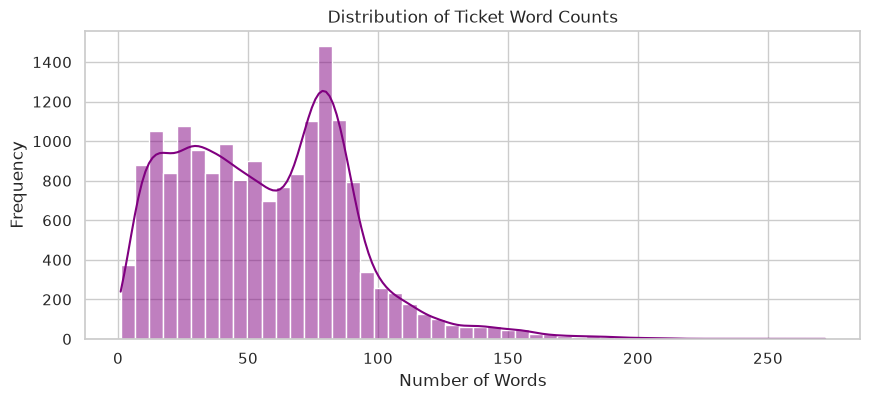

In [27]:
# Calculate word count for each ticket body
df_cleaned["word_count"] = df_cleaned["norm_body"].apply(
    lambda x: len(str(x).split())
)

# Print descriptive statistics for word counts
print("Ticket Word Count Statistics:")
print(df_cleaned["word_count"].describe())

# Plot word count distribution
plt.figure(figsize=(10, 4))
sns.histplot(
    df_cleaned["word_count"], bins=50, kde=True, color="purple", hue=None
)
plt.title("Distribution of Ticket Word Counts")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()